# Part II - Ford GoBike Usage Patterns
## by Beau Hale

## Investigation Overview

This explanatory analysis summarizes the most important findings from the Ford GoBike exploratory analysis. The goal is to explain who used the system, how long typical trips lasted, and when trips were most common.

The key questions are:

1. How long are most typical Ford GoBike trips?
2. Are most trips taken by subscribers or customers?
3. How does trip duration differ between subscribers and customers?
4. When are trips most common by day of week and hour?

## Dataset Overview and Executive Summary

The Ford GoBike dataset contains individual bike-share trips from the greater San Francisco Bay Area during February 2019. The original dataset includes 183,412 trips.

For the explanatory analysis, I created fields for trip duration in minutes, member age, start hour, and day of week. I removed rows missing demographic or station information, filtered member age to 18 through 80, and focused on typical trips of 60 minutes or less.

Summary of findings:

1. Most trips are short, with a typical trip median of about 8.5 minutes.
2. Subscribers take the large majority of trips.
3. Customers tend to ride longer than subscribers.
4. Trip volume is highest during weekday commute hours, especially around 8 AM and 5 PM.

In [1]:
# import all packages and set plots to be embedded inline
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Suppress warnings from the final output
warnings.simplefilter("ignore")

sns.set_style('whitegrid')

In [2]:
# load in the dataset into a pandas dataframe
rides = pd.read_csv('fordgobike-tripdata.csv')

# show first few rows
rides.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [3]:
def clean_gobike_data(df):
    """
    Clean and prepare Ford GoBike data for explanatory visuals.
    """
    clean = df.copy()

    # Convert time columns
    clean['start_time'] = pd.to_datetime(clean['start_time'])
    clean['end_time'] = pd.to_datetime(clean['end_time'])

    # Create analysis fields
    clean['duration_min'] = clean['duration_sec'] / 60
    clean['member_age'] = 2019 - clean['member_birth_year']
    clean['start_hour'] = clean['start_time'].dt.hour
    clean['day_of_week'] = clean['start_time'].dt.day_name()

    # Order day values
    ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    clean['day_of_week'] = pd.Categorical(clean['day_of_week'], categories=ordered_days, ordered=True)

    # Convert selected columns to categorical using a loop
    category_columns = ['user_type', 'member_gender', 'bike_share_for_all_trip']
    for col in category_columns:
        clean[col] = clean[col].astype('category')

    # Remove records missing fields needed for this analysis
    clean = clean.dropna(subset=[
        'member_birth_year',
        'member_gender',
        'start_station_name',
        'end_station_name'
    ]).copy()

    # Keep reasonable ages and typical trips
    clean = clean[clean['member_age'].between(18, 80)]
    typical = clean[clean['duration_min'] <= 60].copy()

    return clean, typical


def format_plot(title, xlabel, ylabel):
    """
    Apply consistent title, labels, and layout.
    """
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(xlabel, fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.tight_layout()


rides_clean, rides_typical = clean_gobike_data(rides)

## Visualization 1: Most Trips Were Short

The first key finding is that Ford GoBike trips were usually short. I focused on typical trips of 60 minutes or less so that a small number of unusually long trips would not distort the main pattern.

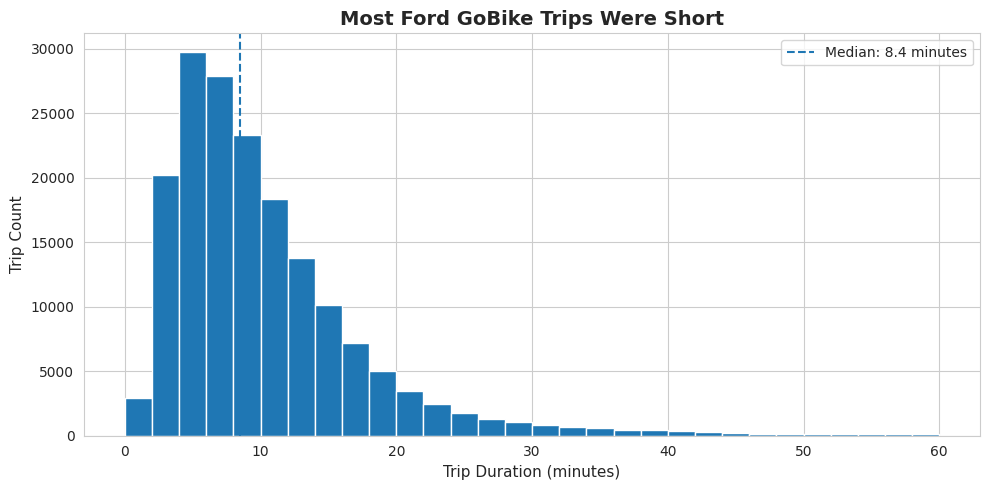

In [4]:
plt.figure(figsize=(10, 5))

bins = np.arange(0, rides_typical['duration_min'].max() + 2, 2)
plt.hist(rides_typical['duration_min'], bins=bins)

median_duration = rides_typical['duration_min'].median()
plt.axvline(
    median_duration,
    linestyle='--',
    label=f'Median: {median_duration:.1f} minutes'
)

format_plot(
    'Most Ford GoBike Trips Were Short',
    'Trip Duration (minutes)',
    'Trip Count'
)

plt.legend()
plt.show()

Most trips were under 15 minutes, and the median typical trip was about 8.5 minutes. This suggests that Ford GoBike was commonly used for short, point-to-point travel.

## Visualization 2: Customers Took Longer Trips Than Subscribers

The second key finding is that customers generally had longer trip durations than subscribers.

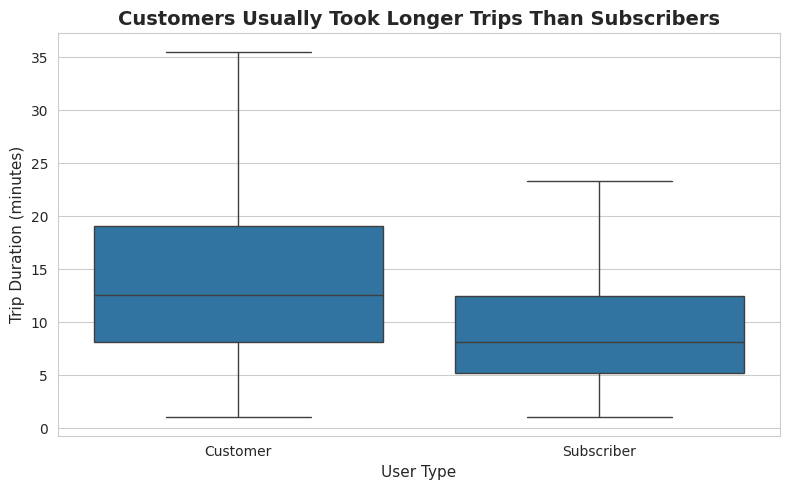

In [5]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=rides_typical,
    x='user_type',
    y='duration_min',
    showfliers=False,
    color=sns.color_palette()[0]
)

format_plot(
    'Customers Usually Took Longer Trips Than Subscribers',
    'User Type',
    'Trip Duration (minutes)'
)

plt.show()

Customers had a higher median trip duration than subscribers. This supports the idea that subscribers were more likely using the system for shorter routine trips, while customers were more likely taking occasional or longer rides.

## Visualization 3: Weekday Commute Periods Had the Highest Trip Counts

The third key finding is that trip volume was highest during weekday commute periods. To make this easier to read, I grouped trip start hours into four time periods.

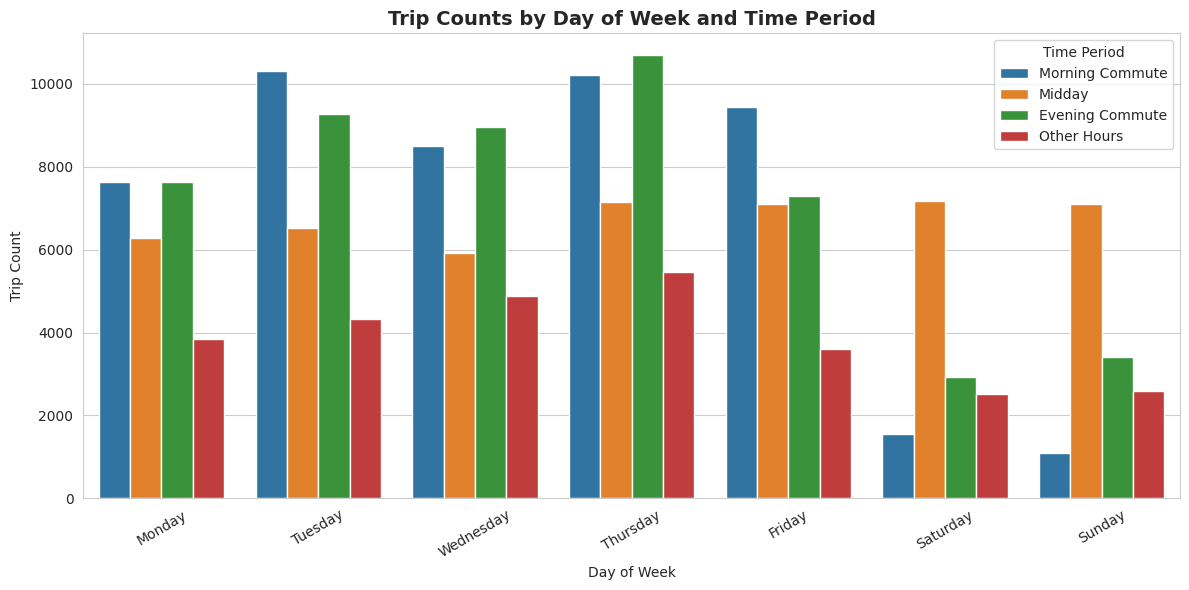

In [6]:
def assign_time_period(hour):
    """
    Group trip start hours into simple daily time periods.
    """
    if 6 <= hour <= 9:
        return 'Morning Commute'
    elif 10 <= hour <= 15:
        return 'Midday'
    elif 16 <= hour <= 18:
        return 'Evening Commute'
    else:
        return 'Other Hours'


rides_typical['time_period'] = rides_typical['start_hour'].apply(assign_time_period)

period_order = ['Morning Commute', 'Midday', 'Evening Commute', 'Other Hours']

period_day_counts = (
    rides_typical
    .groupby(['day_of_week', 'time_period'])
    .size()
    .reset_index(name='trip_count')
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=period_day_counts,
    x='day_of_week',
    y='trip_count',
    hue='time_period',
    hue_order=period_order
)

plt.title('Trip Counts by Day of Week and Time Period', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Trip Count')
plt.xticks(rotation=30)
plt.legend(title='Time Period')

plt.tight_layout()
plt.show()

Trip counts were highest during weekday commute periods, especially during the morning and evening commute windows. Weekend trip counts were lower and less concentrated around commute times. This supports the conclusion that Ford GoBike was heavily used for regular weekday travel.

## Final Summary

The explanatory analysis shows three main findings. First, most Ford GoBike trips were short, with a median typical trip of about 8.5 minutes. Second, subscribers made up most of the system activity, but customers generally took longer rides. Third, trip volume was highest during weekday commute periods, which suggests that the system was commonly used for routine transportation rather than only recreational riding.

These findings match the exploratory analysis and show that user type and trip timing were the clearest factors connected to Ford GoBike usage patterns.